These are data handling and visualization tools.

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


ML models learn better when values are scaled.

LogisticRegression - Placement Yes / No
RandomForestClassifier - Better accuracy for placement
RandomForestRegressor - Predict performance score
KMeans - Group students into clusters

Accuracy → how many correct predictions
Confusion matrix → correct vs wrong
RMSE / R² → regression performance

pickle - To save trained models so Flask can use them without retraining.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble import RandomForestRegressor

from sklearn.cluster import KMeans



from sklearn.metrics import(accuracy_score,classification_report,confusion_matrix,mean_squared_error,r2_score)

import pickle

Loads placement dataset into a table (DataFrame).

In [126]:
df=pd.read_csv("Placement_Data_Full_Class.csv")
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


info() → column types

describe() → statistics (mean, min, max)

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


salary → missing values (not useful for prediction)

sl_no → just index, no meaning

ML models should not learn useless data.

In [128]:
df.drop(columns=["salary","sl_no"],inplace=True,errors="ignore")

Label Encoding.

In [129]:

df["status"] = df["status"].map({"Placed": 1, "Not Placed": 0})


Original dataset did not have projects/certifications,
but they are important in real placement scenarios.

In [130]:
np.random.seed(42)
df["projects"]=np.random.randint(1,6,size=len(df))
df["certification"]=np.random.randint(0,4,size=len(df))

One-Hot Encoding

In [131]:
categorical_cols=df.select_dtypes(include="object").columns
print("categorical columns:",categorical_cols)
df=pd.get_dummies(df,columns=categorical_cols,drop_first=True)


categorical columns: Index(['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex',
       'specialisation'],
      dtype='object')


Convert True/False → 1/0

In [132]:
bool_cols=df.select_dtypes(include="bool").columns
df[bool_cols]=df[bool_cols].astype(int)

Feature Selection

X → input features (student data)

y → output (placed or not)

In [133]:
FINAL_FEATURES = [
    'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p',
    'projects', 'certification',
    'gender_M', 'ssc_b_Others', 'hsc_b_Others',
    'hsc_s_Commerce', 'hsc_s_Science',
    'degree_t_Others', 'degree_t_Sci&Tech',
    'workex_Yes', 'specialisation_Mkt&HR'
]

X = df[FINAL_FEATURES]
y = df["status"]

print("Number of features used:", X.shape[1])

Number of features used: 16


Marks are in different ranges:

MBA % → 50–80

Projects → 1–5

Scaler converts all to same scale so model learns fairly.

In [134]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaler expects:", scaler.n_features_in_)

Scaler expects: 16


Train → 80%

Test → 20%

To check how model performs on new students.

In [135]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


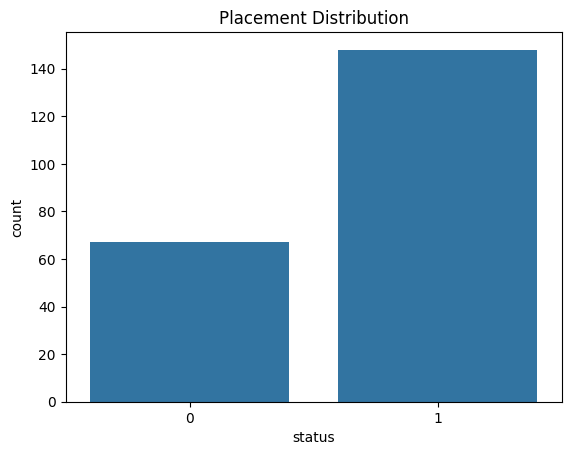

In [136]:
sns.countplot(x="status",data=df)
plt.title("Placement Distribution")
plt.show()

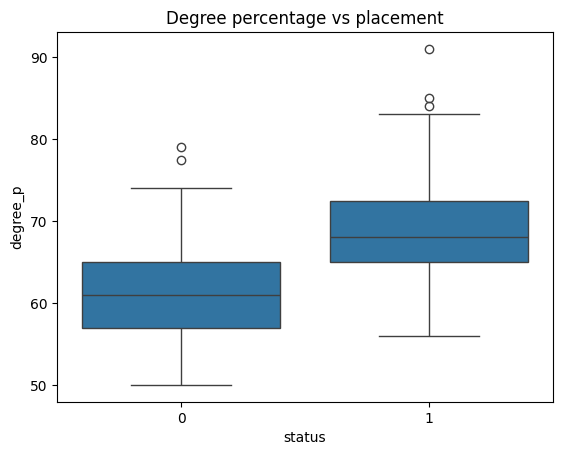

In [137]:
sns.boxplot(x="status",y="degree_p",data=df)
plt.title("Degree percentage vs placement")
plt.show()

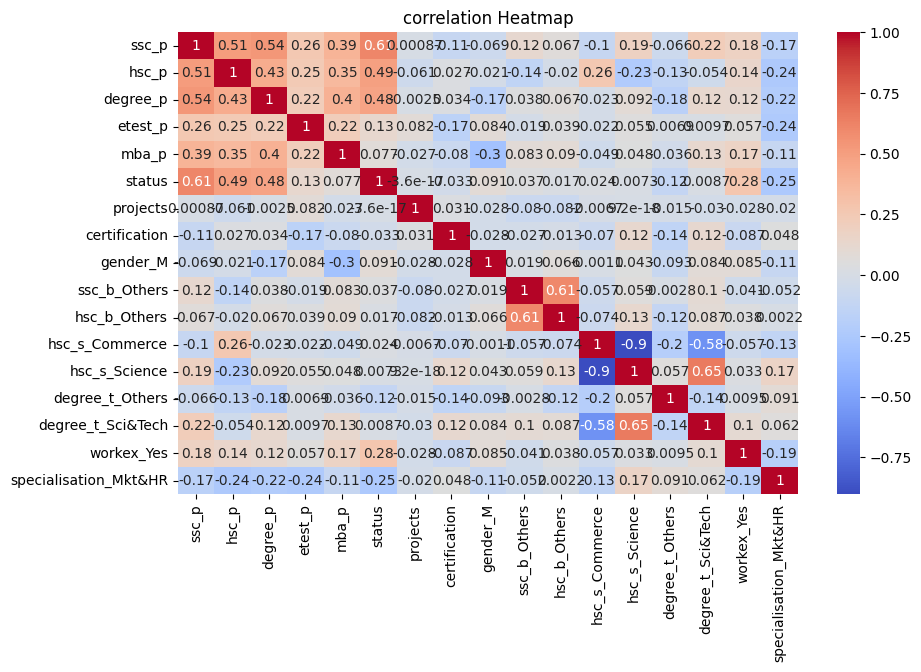

In [138]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("correlation Heatmap")
plt.show()

In [139]:
X.columns

Index(['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'projects',
       'certification', 'gender_M', 'ssc_b_Others', 'hsc_b_Others',
       'hsc_s_Commerce', 'hsc_s_Science', 'degree_t_Others',
       'degree_t_Sci&Tech', 'workex_Yes', 'specialisation_Mkt&HR'],
      dtype='object')

In [140]:
print(X.shape)   # must be (?, 16)


(215, 16)


Logistic Regression (Baseline Model)

In [141]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)
print("logistic regression accuracy:",accuracy_score(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))

logistic regression accuracy: 0.8837209302325582
              precision    recall  f1-score   support

           0       0.82      0.75      0.78        12
           1       0.91      0.94      0.92        31

    accuracy                           0.88        43
   macro avg       0.86      0.84      0.85        43
weighted avg       0.88      0.88      0.88        43



Random Forest Classifier (Final Model)

Combines many decision trees,Reduces overfitting,High accuracy

main placement prediction model

In [142]:
rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
print("Random Forest Accuracy:",accuracy_score(y_test,y_pred_rf))

Random Forest Accuracy: 0.7906976744186046


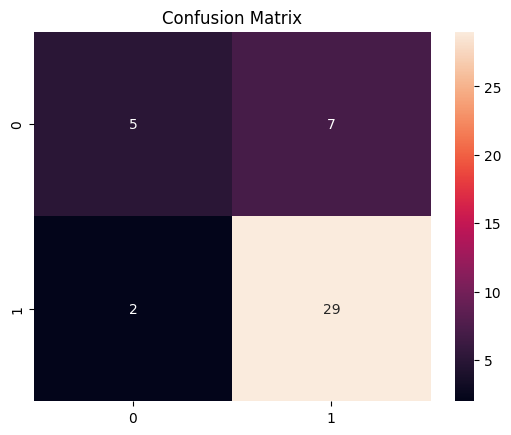

In [143]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()


Performance Score (Regression)

To give numerical score showing student strength.

 Makes project more advanced than simple yes/no


In [144]:
df["performance_score"] = (
    df["degree_p"] * 0.4 +
    df["mba_p"] * 0.3 +
    df["projects"] * 5 +
    df["certification"] * 3 +
    df["workex_Yes"] * 10
)


In [145]:
X_reg = df.drop(["status", "performance_score"], axis=1)
y_reg = df["performance_score"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


Predicts continuous value (performance score).

In [146]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(Xr_train, yr_train)

pred_rf = rf_reg.predict(Xr_test)
print("RMSE:", np.sqrt(mean_squared_error(yr_test, pred_rf)))
print("R2 Score:", r2_score(yr_test, pred_rf))


RMSE: 2.6508768751000216
R2 Score: 0.928508484106691


Clustering (Unsupervised Learning)

Groups students into High potential , Medium , Low


In [147]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters


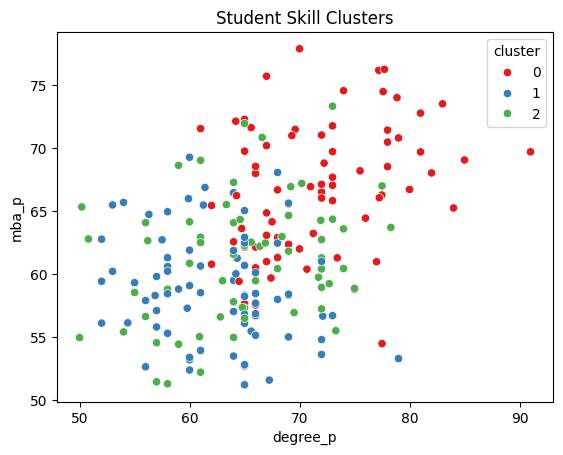

In [148]:
sns.scatterplot(
    x=df["degree_p"],
    y=df["mba_p"],
    hue=df["cluster"],
    palette="Set1"
)
plt.title("Student Skill Clusters")
plt.show()


Save Models

In [149]:
pickle.dump(rf, open("classifier.pkl", "wb"))
pickle.dump(rf_reg, open("regressor.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(kmeans, open("kmeans.pkl", "wb"))


This project predicts whether a student will get placed using academic performance, skills, and experience.
We cleaned data, encoded categorical values, scaled features, trained multiple ML models, evaluated performance, added performance scoring, clustering, and finally deployed it using Flask as a web application.